In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import MDAnalysis as mda

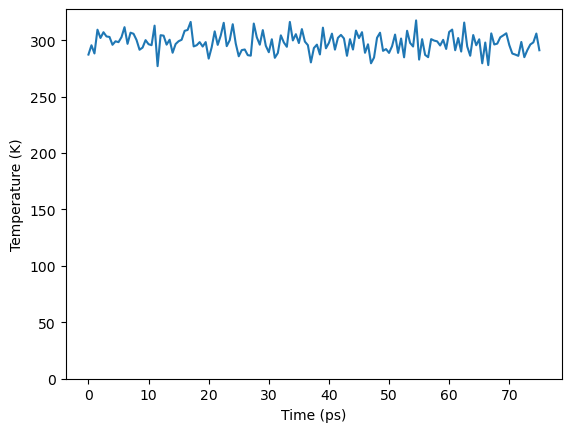

In [2]:
"""
Step1: Data loading from the trajectory file, and eqbr determination
"""
u=mda.Universe("final_nvt_equilibrated.data", "Water.lammpstrj", format="LAMMPSDUMP", lengthunit="A", timeunit="fs", dt=20, atom_style="id mol type q x y z")
Water=u.atoms
n_atoms=len(Water)
n_water=int(n_atoms/3)
n_frames=len(u.trajectory)
box=19.711200000000002

Oxygen=np.empty((n_frames, n_water, 3))
Hydrogen1=np.empty((n_frames, n_water, 3))
Hydrogen2=np.empty((n_frames, n_water, 3))

for i, ts in enumerate(u.trajectory):
    frame_coords=Water.positions

    Oxygen[i]=frame_coords[0::3, :]%box                                         #0::3: Start from 0, then take every 3rd atom from there (like 0, 3, 6)
    Hydrogen1[i]=frame_coords[1::3, :]%box
    Hydrogen2[i]=frame_coords[2::3, :]%box

T_data=pd.read_csv("log.lammps", sep=r"\s+", skiprows=107, nrows=151)
step=T_data["Step"].values
time=np.array(step*0.5/1000)                                                      #Time in ps
Temps=np.array(T_data["Temp"].values)
plt.ylim(0, np.max(Temps)+10)
plt.plot(time, Temps)
plt.xlabel("Time (ps)")
plt.ylabel("Temperature (K)")
plt.show()

In [3]:
"""
Step2: Important parameters for calculations
"""

n_skip=int(0*n_frames)                                                                                                #Data is already equilibrated, so we don't need to skip anything (from the temperature plot)!
time=np.linspace(0, 75, n_frames)
dt=0.5                                                                                                                #Time step in fs
dump_freq=20                                                                                                        #Dump frequency in frames
time_bw_frames=dt*dump_freq
n_blocks=4
n_framesperblock=n_frames//n_blocks
traj_frac=0.40
maxlagtime=n_framesperblock*traj_frac*time_bw_frames
n_framesmaxlag=int(maxlagtime/time_bw_frames)
n_initial=int(n_framesperblock-n_framesmaxlag)                                                                        #Possible values of starting times

cutoff_angle=30                                                                                                       #H*O*O angle in degrees
cutoff_dist_OO=3.5                                                                                                    #O*-O distance in angstroms
cutoff_dist_OH=2.45                                                                                                   #O-H* distance in angstroms

#Minimum Image Convention function
def MIC(dirn):
    dir=dirn-np.round(dirn/box)*box
    return dir

In [4]:
"""
Step3: Actual Calculations, finding the correlations for every block, and then doing the block averages
"""
corr_dir=np.zeros((n_framesmaxlag, n_blocks))

H_bond1=np.full((n_frames, n_water), -1, dtype=np.int16)
H_bond2=np.full((n_frames, n_water), -1, dtype=np.int16)

norm_u_OO_H_bond1=np.zeros((n_frames, n_water, 3), dtype=np.float32)
norm_u_OO_H_bond2=np.zeros((n_frames, n_water, 3), dtype=np.float32)

nanb=np.zeros((n_framesmaxlag, n_blocks))
#All the O-O distances
for t in range(n_frames):
    u_OO=MIC(Oxygen[t][np.newaxis, :, :]-Oxygen[t][:, np.newaxis, :])
    dist_OO=np.linalg.norm(u_OO, axis=2)

    #Normalized Vectors
    norm_u_OO=np.zeros_like(u_OO)
    np.divide(u_OO, dist_OO[:, :, np.newaxis], out=norm_u_OO, where=dist_OO[:, :, np.newaxis]>0.1)                  #This way of normalising is faster, and we're ensuring that the dist=0 (self) cases are not considered
    
    #Qualifying OO pairs (for H-bond) (and we shouldn't compare an O with itself)
    qual_OO=(dist_OO<=cutoff_dist_OO)&(dist_OO>0.1)

    #Check with H1
    #distance
    u_OH1=MIC(Hydrogen1[t][:, np.newaxis, :]-Oxygen[t][np.newaxis, :, :])
    dist_OH1=np.linalg.norm(u_OH1, axis=2)
    #qual_OH1=(dist_OH1<=cutoff_dist_OH)

    #angle: Only the corresponding O and H are to be taken now!
    u_OH1_intra=MIC(Hydrogen1[t]-Oxygen[t])
    norm_u_OH1_intra=u_OH1_intra/np.linalg.norm(u_OH1_intra, axis=1)[:, np.newaxis]
    angle_OH1_OO=np.degrees(np.arccos(np.clip(np.einsum("id, ijd->ij", norm_u_OH1_intra, norm_u_OO), -1.0, 1.0)))
    qual_angle_OH1_OO=(angle_OH1_OO<=cutoff_angle)

    #All qualifications combined
    qual_H1Bond=(qual_OO)&(qual_angle_OH1_OO)#&(qual_OH1)
    donorH1, acceptorO=np.where(qual_H1Bond)                                                                        #Look at the angle definition, the first is OH and second is OO, so the first corresponds to H and the second to O
    H_bond1[t, donorH1]=acceptorO

    #Now, check with H2
    #distance
    u_OH2=MIC(Hydrogen2[t][:, np.newaxis, :]-Oxygen[t][np.newaxis, :, :])
    dist_OH2=np.linalg.norm(u_OH2, axis=2)
    #qual_OH2=(dist_OH2<=cutoff_dist_OH)

    #angle: Only the corresponding O and H are to be taken now!
    u_OH2_intra=MIC(Hydrogen2[t]-Oxygen[t])
    norm_u_OH2_intra=u_OH2_intra/np.linalg.norm(u_OH2_intra, axis=1)[:, np.newaxis]
    angle_OH2_OO=np.degrees(np.arccos(np.clip(np.einsum("id, ijd->ij", norm_u_OH2_intra, norm_u_OO), -1.0, 1.0)))
    qual_angle_OH2_OO=(angle_OH2_OO<=cutoff_angle)

    #All qualifications combined
    qual_H2Bond=(qual_OO)&(qual_angle_OH2_OO)#&(qual_OH2)
    donorH2, acceptorO=np.where(qual_H2Bond)
    H_bond2[t, donorH2]=acceptorO

n_jumps=np.zeros((n_framesmaxlag, n_blocks))
total_bonds_tracked=np.zeros((n_framesmaxlag, n_blocks))

for i in range(n_blocks):
    starting=i*n_framesperblock
    print(f"Block{i} started")
    for j in range(n_initial):
        ind_in=starting+j
        
        H1_0=H_bond1[ind_in]
        H2_0=H_bond2[ind_in]

        HB1_in=(H1_0!=-1)
        HB2_in=(H2_0!=-1)
        
        n_started_bonds=np.sum(HB1_in)+np.sum(HB2_in)
        
        H1_lag=H_bond1[ind_in:ind_in+n_framesmaxlag]
        H2_lag=H_bond2[ind_in:ind_in+n_framesmaxlag]

        switch_event1=(H1_lag!=H1_0)&(H1_lag!=-1)
        switch_event2=(H2_lag!=H2_0)&(H2_lag!=-1)
        
        first_switch1=np.argmax(switch_event1, axis=0)
        first_switch2=np.argmax(switch_event2, axis=0)

        never1=~np.any(switch_event1, axis=0)
        never2=~np.any(switch_event2, axis=0)

        first_switch1[never1]=n_framesmaxlag
        first_switch2[never2]=n_framesmaxlag

        t=np.arange(n_framesmaxlag)[:, np.newaxis]

        jumped1=(t>=first_switch1[np.newaxis, :]) & HB1_in[np.newaxis, :]
        jumped2=(t>=first_switch2[np.newaxis, :]) & HB2_in[np.newaxis, :]

        nanb[:, i]+=(np.sum(jumped1, axis=1)+np.sum(jumped2, axis=1))
        total_bonds_tracked[:, i]+=n_started_bonds

total_bonds_tracked[total_bonds_tracked==0]=1
normalized_jump_fraction=nanb/total_bonds_tracked
tcf=1.0-normalized_jump_fraction

Block0 started
Block1 started
Block2 started
Block3 started


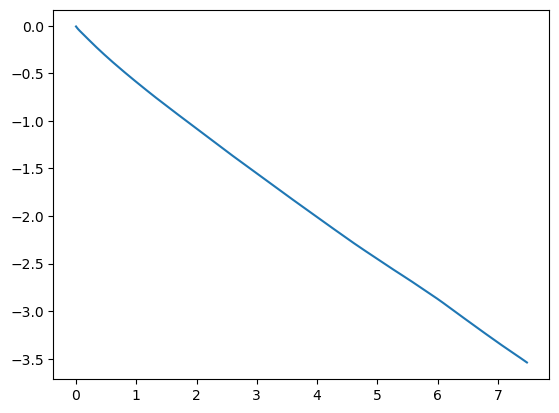

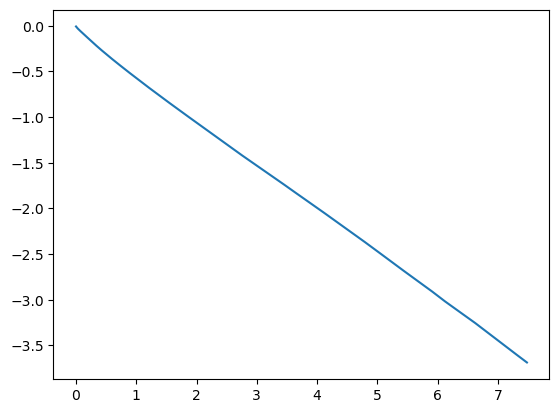

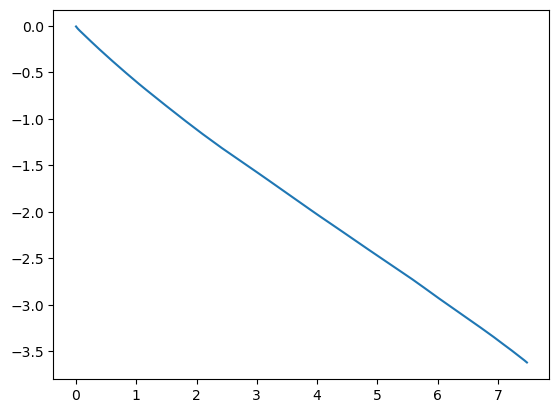

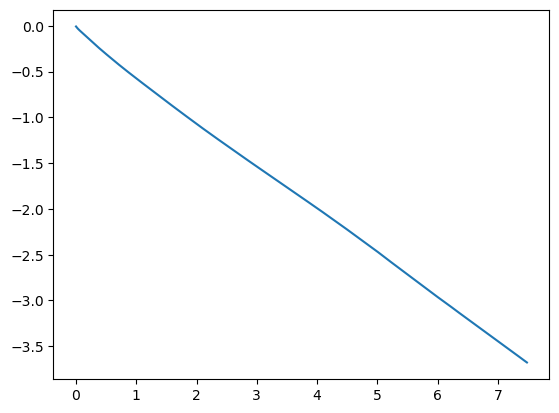

In [5]:
tcf_avg=np.mean(tcf, axis=-1)
block_jump_time=np.zeros(n_blocks)
block_jump_fit=np.zeros(n_blocks)
intercept=np.zeros(n_blocks)

for i in range(n_blocks):
    y_block=tcf[1:, i]
    x_block=time[:len(y_block)]
    plt.plot(x_block, np.log(y_block))
    plt.show()

Jump Time using exponential fitting for block 0=2.17ps
Jump Time for block 0 using integral method=1.86ps
Jump Time using exponential fitting for block 1=2.08ps
Jump Time for block 1 using integral method=1.87ps
Jump Time using exponential fitting for block 2=2.15ps
Jump Time for block 2 using integral method=1.83ps
Jump Time using exponential fitting for block 3=2.09ps
Jump Time for block 3 using integral method=1.87ps

Mean Jump Time (Integral) (ps): 1.86
Stdev Jump Time (Integral): 0.02

Mean Jump Time (Exponential) (ps): 2.12
Stdev Jump Time (Exponential): 0.04


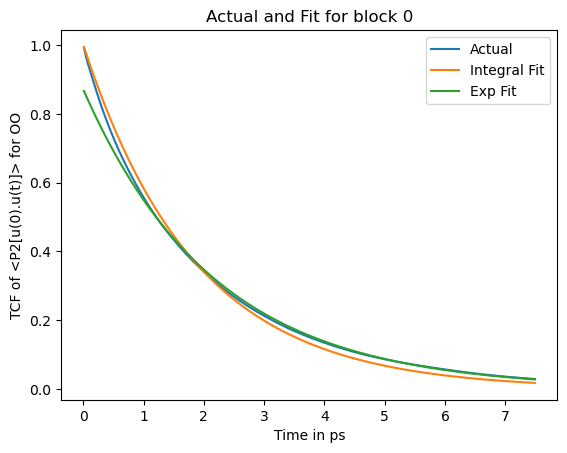

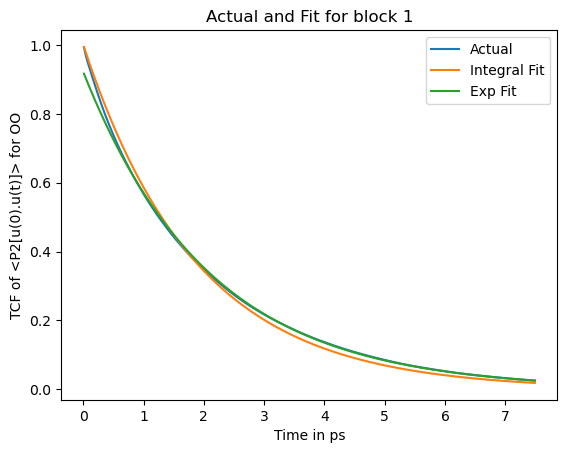

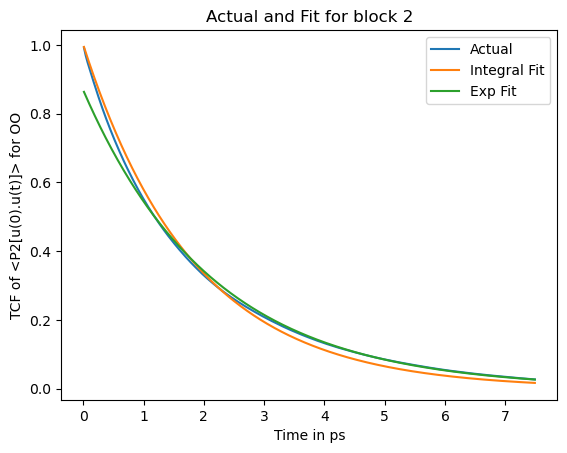

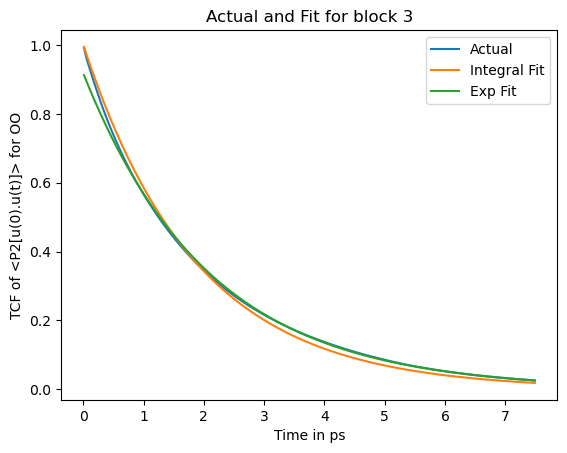

In [6]:
for i in range(n_blocks):
    y_block=tcf[1:, i]
    x_block=time[:len(y_block)]
    yb=y_block[int(0*len(y_block)): int(1*len(y_block))]
    xb=x_block[int(0*len(y_block)): int(1*len(y_block))]
    jump_time=np.trapezoid(yb, xb)
    block_jump_time[i]=jump_time
    block_jump_fit[i], intercept[i]=np.polyfit(xb, np.log(yb), 1)
    print(f"Jump Time using exponential fitting for block {i}={-1.0/block_jump_fit[i]:.2f}ps")
    print(f"Jump Time for block {i} using integral method={block_jump_time[i]:.2f}ps")

print(f'\nMean Jump Time (Integral) (ps): {np.mean(block_jump_time):.2f}')
print(f'Stdev Jump Time (Integral): {np.std(block_jump_time):.2f}')

print(f'\nMean Jump Time (Exponential) (ps): {np.mean(-1.0/block_jump_fit):.2f}')
print(f'Stdev Jump Time (Exponential): {np.std(-1.0/block_jump_fit):.2f}')

for i in range(n_blocks):
    t_plot=time[1:int(0.40*(1/n_blocks)*len(time))]
    exp_fit=np.exp(intercept[i]+1.0*t_plot*block_jump_fit[i])
    corr_fit=np.exp(-1.0*t_plot/block_jump_time[i])
    plt.plot(t_plot, tcf[1:1+len(t_plot), i], label="Actual")
    plt.plot(t_plot, corr_fit, label="Integral Fit")
    plt.plot(t_plot, exp_fit, label="Exp Fit")
    plt.xlabel("Time in ps")
    plt.ylabel("TCF of <P2[u(0).u(t)]> for OO")
    plt.title(f"Actual and Fit for block {i}")
    plt.legend()
    plt.show()

In [7]:
x=np.array([[False, False, True, True, False, True, False, False], [False, False, False, True, False, True, False, True], [True, False, False, True, False, True, False, False], [False, False, False, False, False, False, False, False]])
print(x)

[[False False  True  True False  True False False]
 [False False False  True False  True False  True]
 [ True False False  True False  True False False]
 [False False False False False False False False]]


In [8]:
print(np.argmax(x, axis=1))
print(~np.any(x, axis=0))

[2 3 0 0]
[False  True False False  True False  True False]


In [9]:
y=np.array([1, 2, 3, 4])
print(y[None, 1])
print(y[1])
print(y[1, None])
print(y[:, None])

[2]
2
[2]
[[1]
 [2]
 [3]
 [4]]


In [10]:
z=np.arange(4)[:, None]
print(z)

[[0]
 [1]
 [2]
 [3]]


In [11]:
print(jumped1)

[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]]
